## **Cálculo del Radio de Giro** 

In [12]:
from funciones import calcular_radio_giro_promedio
import os
import gsd.hoomd
import numpy as np

In [13]:
def mapear_orden_cadenas_por_enlaces(frame, num_cadenas, longitud_cadena):
    """
    Utiliza la matriz de bonds para reconstruir la lista de índices de partículas
    en el orden molecular exacto (de cabeza a cola para cada cadena).
    """
    enlaces = frame.bonds.group
    
    # Creamos un diccionario de adyacencia (lista de vecinos)
    adj = {}
    for u, v in enlaces:
        if u not in adj: adj[u] = []
        if v not in adj: adj[v] = []
        adj[u].append(v)
        adj[v].append(v) # Para búsquedas bidireccionales si fuera necesario

    mapa_indices_ordenados = []
    
    # Tus datos muestran que las cabezas de las cadenas inician del índice 0 al (num_cadenas - 1)
    for cabeza in range(num_cadenas):
        cadena_actual = [cabeza]
        nodo_actual = cabeza
        
        # Caminamos a lo largo de los enlaces para encontrar los g-1 miembros restantes
        for _ in range(longitud_cadena - 1):
            vecinos = adj.get(nodo_actual, [])
            # Buscamos el vecino que NO hayamos agregado ya a la cadena
            siguiente_nodo = [v for v in vecinos if v not in cadena_actual]
            if siguiente_nodo:
                nodo_actual = siguiente_nodo[0]
                cadena_actual.append(nodo_actual)
            else:
                break # Por seguridad si se corta la cadena
                
        mapa_indices_ordenados.extend(cadena_actual)
        
    return np.array(mapa_indices_ordenados)

In [14]:
# ###############     Ejecución del Script      #######################

grado_polimerizacion = [8, 16, 24]
frame_inicial = 200
ruta_archivo_base = '/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P12_Polimero_Solvente'
temperaturas = [0.60, 0.65]
resultados = {}

for T in temperaturas:
    # Agregamos los resultados clasificados por temperaturas
    resultados[T] = {
        'Rg': [],
        'Rg_std': []
    }

    for g in grado_polimerizacion:
        archivo = f'Poly-Solv_T{T:.2f}_epsSP1.00_monom_{g}.gsd'
        ruta_final = os.path.join(ruta_archivo_base, archivo)
        
        print(f'Analizando: {archivo}')
        
        try:
            with gsd.hoomd.open(name=ruta_final, mode='r') as trayectoria:
                num_frames = len(trayectoria)
                frames_analisis = num_frames - frame_inicial
                primer_frame = trayectoria[0]
                
                tipos_particulas = primer_frame.particles.types
                num_particulas = primer_frame.particles.N
                id_polimero = tipos_particulas.index('P')

                filtro_polimero = (primer_frame.particles.typeid == id_polimero)
                num_monomeros = np.sum(filtro_polimero)
                num_cadenas = num_monomeros // g

                print(f'  -> Total frames: {num_frames}')
                print(f'  -> Frame inicial {frame_inicial}')
                print(f'  -> Frames a analizar: {frames_analisis}')
                print(f'  -> Total de partículas: {num_particulas}')
                print(f"  -> Monómeros de polímero: {num_monomeros}")
                print(f"  -> Cadenas independientes: {num_cadenas}")

                # --- NUEVA ETAPA: Construir el mapa de ordenamiento molecular ---
                print("  -> Reconstruyendo topología molecular desde los enlaces...")
                indices_ordenados_totales = mapear_orden_cadenas_por_enlaces(primer_frame, num_cadenas, g)

                trayectoria_polimero = np.empty((frames_analisis, num_monomeros, 3))
                # Revisamos la cantidad de cajas que hubo durante la simulación
                cajas_trayectoria = np.empty((frames_analisis, 3))

                for i, frame in enumerate(trayectoria[frame_inicial:]):
                    # Extraemos la caja de cada frame
                    cajas_trayectoria[i] = frame.configuration.box[:3]

                    posiciones_todas = frame.particles.position

                    # Filtramos los monómeros durante cada frame
                    filtro_dinamico = (frame.particles.typeid == id_polimero)
                    trayectoria_polimero[i] = posiciones_todas[indices_ordenados_totales]
                    

                # El cálculo se queda ADENTRO del bloque para asegurar que el archivo se leyó bien
                rg_promedio, std_rg, lista_rg = calcular_radio_giro_promedio(trayectoria_polimero, longitud_cadenas=g, dimensiones_caja=cajas_trayectoria)
                
                print(f"  -> Radio de Giro Promedio: {rg_promedio:.4f}")
                print(f"  -> Desviación estándar: {std_rg:.4f}\n")

                resultados[T]['Rg'].append(rg_promedio)
                resultados[T]['Rg_std'].append(std_rg)


        except FileNotFoundError:
            print(f'  [ERROR] No se encontró el archivo: {archivo}\n')
        except Exception as e:
            print(f'  [ERROR] Ocurrió un problema inesperado analizando {archivo}: {e}\n')
            # Importante: Esto te dirá el error real si algo falla adentro
            import traceback
            print(f'  [ERROR] Ocurrió un problema de ejecución:\n{traceback.format_exc()}\n')

Analizando: Poly-Solv_T0.60_epsSP1.00_monom_8.gsd
  -> Total frames: 264
  -> Frame inicial 200
  -> Frames a analizar: 64
  -> Total de partículas: 240000
  -> Monómeros de polímero: 2400
  -> Cadenas independientes: 300
  -> Reconstruyendo topología molecular desde los enlaces...
  -> Radio de Giro Promedio: 0.8962
  -> Desviación estándar: 0.1359

Analizando: Poly-Solv_T0.60_epsSP1.00_monom_16.gsd
  -> Total frames: 421
  -> Frame inicial 200
  -> Frames a analizar: 221
  -> Total de partículas: 240000
  -> Monómeros de polímero: 2400
  -> Cadenas independientes: 150
  -> Reconstruyendo topología molecular desde los enlaces...
  -> Radio de Giro Promedio: 1.1293
  -> Desviación estándar: 0.1278

Analizando: Poly-Solv_T0.60_epsSP1.00_monom_24.gsd
  -> Total frames: 540
  -> Frame inicial 200
  -> Frames a analizar: 340
  -> Total de partículas: 240000
  -> Monómeros de polímero: 2400
  -> Cadenas independientes: 100
  -> Reconstruyendo topología molecular desde los enlaces...
  -> Ra

In [18]:
# Agregado de resultados 
print(resultados)

{0.6: {'Rg': [np.float64(0.8962440494752324), np.float64(1.1292504099756278), np.float64(1.2369205310466846)], 'Rg_std': [np.float64(0.13586875493694192), np.float64(0.12782151100516354), np.float64(0.10663710725986786)]}, 0.65: {'Rg': [np.float64(0.9165218833809777), np.float64(1.1819195657692427), np.float64(1.3094305591923543)], 'Rg_std': [np.float64(0.14339404112276255), np.float64(0.1536637234968441), np.float64(0.12822390111705012)]}}


Resultados del ajuste para T = 0.6:
  -> Exponente (v): 0.292 ± 0.031
  -> Coeficiente R²: 0.9896
Resultados del ajuste para T = 0.65:
  -> Exponente (v): 0.323 ± 0.033
  -> Coeficiente R²: 0.9905


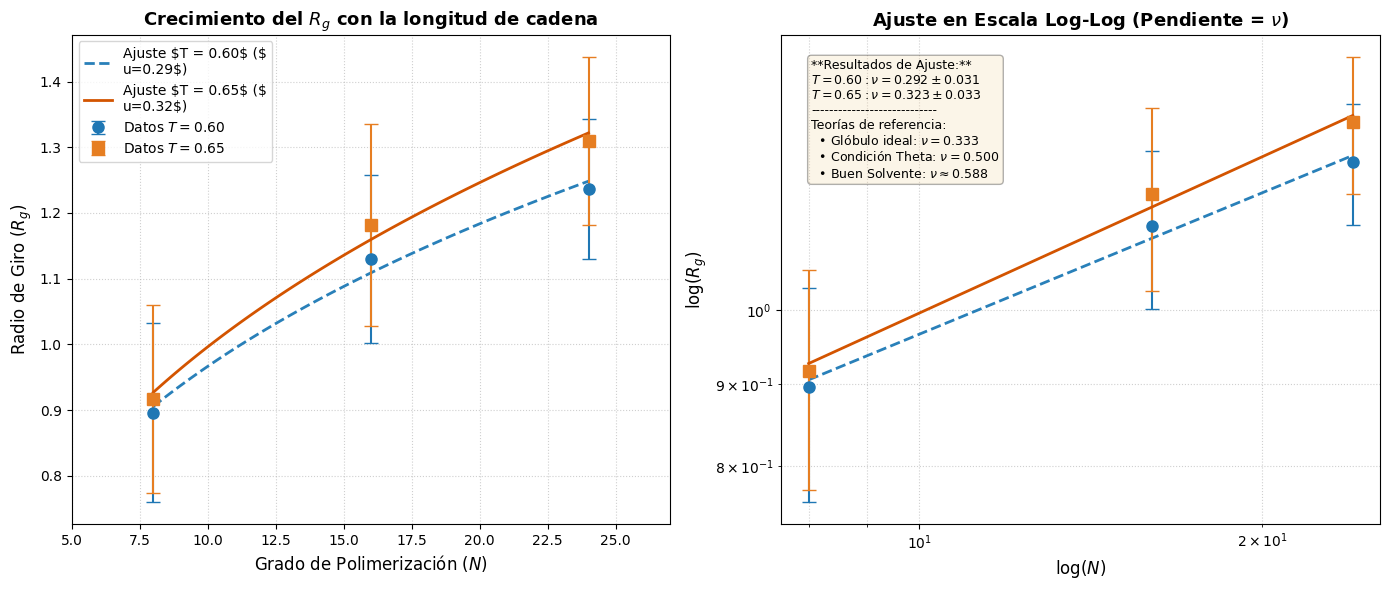

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Supongamos que tu variable de grados de polimerización sigue siendo la misma
N = np.array(grado_polimerizacion) 
N_linea = np.linspace(N.min(),N.max() , 100)

# 1. Definición de la función de ajuste (Ley de potencias)
def ley_potencias(N, A, nu):
    return A * (N**nu)



# Paletas de colores dinámicas para diferenciar las temperaturas
# Puedes añadir más colores si en el futuro agregas más temperaturas
colores_puntos = {0.60: '#1f77b4', 0.65: '#e67e22'}  # Azul y Naranja
colores_lineas = {0.60: '#2980b9', 0.65: '#d35400'}
estilos_linea = {0.60: '--', 0.65: '-'}
marcadores = {0.60: 'o', 0.65: 's'}  # Círculo y Cuadrado

texto_acumulado_ajustes = "**Resultados de Ajuste:**\n"

# --- Configuración del Gráfico con Matplotlib ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# 2. Bucle principal para iterar sobre el diccionario 'resultados'
for T, datos in resultados.items():

    # Extraemos los datos del diccionario convirtiéndolos a arreglos de numpy
    Rg = np.array(datos['Rg'])
    Rg_std = np.array(datos['Rg_std'])
    
    # Realizamos el ajuste no lineal para la temperatura actual (T)
    popt, pcov = curve_fit(ley_potencias, N, Rg, p0=[0.3, 0.5])
    A_opt, nu_opt = popt
    nu_err = np.sqrt(np.diag(pcov))[1]
    
    # Generamos la curva continua de ajuste para esta temperatura
    Rg_ajuste = ley_potencias(N_linea, A_opt, nu_opt)
    Rg_predicho = ley_potencias(N, A_opt, nu_opt)

    # Aplicamos la suma de R2
    residuo = np.sum((Rg - Rg_predicho) ** 2)
    suma_total_cuadrados = np.sum((Rg - np.mean(Rg)) ** 2)
    r_cuadrado = 1 - (residuo / suma_total_cuadrados)

    print(f"Resultados del ajuste para T = {T}:")
    print(f"  -> Exponente (v): {nu_opt:.3f} ± {nu_err:.3f}")
    print(f"  -> Coeficiente R²: {r_cuadrado:.4f}")
    
    # Guardamos los textos informativos para ponerlos luego en la caja de texto
    texto_acumulado_ajustes += f"$T = {T:.2f}: \\nu = {nu_opt:.3f} \\pm {nu_err:.3f}$\n"
    
    # --- Configuración visual por temperatura ---
    color_p = colores_puntos.get(T, '#7f8c8d')  # Color por defecto gris si no está en el mapa
    color_l = colores_lineas.get(T, '#95a5a6')
    estilo = estilos_linea.get(T, '-')
    marcador = marcadores.get(T, '^')

    # --- GRAFICAR EN FIGURA 1 (Escala Lineal) ---
    ax1.errorbar(N, Rg, yerr=Rg_std, fmt=marcador, color=color_p, ecolor=color_p, 
                 capsize=5, markersize=8, label=f'Datos $T = {T:.2f}$')
    ax1.plot(N_linea, Rg_ajuste, estilo, color=color_l, linewidth=2,
             label=f'Ajuste $T = {T:.2f}$ ($\nu={nu_opt:.2f}$)')

    # --- GRAFICAR EN FIGURA 2 (Escala Log-Log) ---
    ax2.errorbar(N, Rg, yerr=Rg_std, fmt=marcador, color=color_p, ecolor=color_p, capsize=5, markersize=8)
    ax2.plot(N_linea, Rg_ajuste, estilo, color=color_l, linewidth=2)


# --- Detalles Finales del Gráfico (Fuera del bucle for) ---

# Ajustes de la FIGURA 1
ax1.set_xlabel('Grado de Polimerización ($N$)', fontsize=12)
ax1.set_ylabel('Radio de Giro ($R_g$)', fontsize=12)
ax1.set_title('Crecimiento del $R_g$ con la longitud de cadena', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_xlim(5, 27)
ax1.legend(fontsize=10, loc='upper left')

# Ajustes de la FIGURA 2
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('$\log(N)$', fontsize=12)
ax2.set_ylabel('$\log(R_g)$', fontsize=12)
ax2.set_title('Ajuste en Escala Log-Log (Pendiente = $\\nu$)', fontsize=13, fontweight='bold')
ax2.grid(True, which="both", linestyle=':', alpha=0.6)

# Añadir la caja de texto unificada con la interpretación física dentro de la gráfica 2
texto_completo = (
    f"{texto_acumulado_ajustes}"
    f"----------------------------\n"
    f"Teorías de referencia:\n"
    f"  • Glóbulo ideal: $\\nu = 0.333$\n"
    f"  • Condición Theta: $\\nu = 0.500$\n"
    f"  • Buen Solvente: $\\nu \\approx 0.588$"
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.3)
ax2.text(0.05, 0.95, texto_completo, transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()